# Synthetic Volume Validation — Two More Models

Same methodology as `synthetic_volume_validation.ipynb`, applied to **two new
synthetic scenes** with different geometry, so the brute-force calibration of the
two estimators (`compute_voxel_volume`, `compute_slice_volume`) is tested beyond
the original "spheres + boxes" vineyard.

For each model we:
1. fill a **disjoint, known-volume** composite at the real cloud's measured density,
2. **visualize** it (interactive Plotly + a saved 3-projection PNG),
3. sweep **voxel size** and **alpha radius `rmax`**, and pick the value that best
   matches the closed-form ground-truth volume.

**The two new scenes (chosen to stress different failure modes):**

- **Model B — "Olive grove":** trunk *cylinders* + canopy *cones*. The cone's
  cross-section shrinks with height, unlike a sphere/box — a different test for the
  Z-slice integrator.
- **Model C — "Two-row vineyard + alley":** two continuous *box* canopy walls
  separated by a 1 m alley. This directly stresses the alpha-shape `rmax`: once
  `rmax` exceeds the alley width it bridges the two rows and over-counts the empty
  lane — the documented failure mode of the slice method.

In [1]:
import os, sys
import numpy as np
import laspy
import matplotlib
import matplotlib.pyplot as plt

for cand in (os.getcwd(),
             "/home/luka/Coding/DIPLOMSKI-RAD/vegetation-pcd-analysis/scripts/pipeline"):
    if cand not in sys.path:
        sys.path.insert(0, cand)
from compute_row_features import compute_voxel_volume, compute_slice_volume  # production fns, unchanged

REAL_LAS = "/home/luka/Coding/DIPLOMSKI-RAD/datasource/flights/2025-07-15-MS_Vinograd_1.las"
IMG_DIR  = os.path.join(os.getcwd(), "images", "synthetic_validation_extra")
os.makedirs(IMG_DIR, exist_ok=True)
RNG = np.random.default_rng(11)
print("Imported:", compute_voxel_volume.__name__, "+", compute_slice_volume.__name__, "| images ->", IMG_DIR)

Imported: compute_voxel_volume + compute_slice_volume | images -> /home/luka/Coding/DIPLOMSKI-RAD/vegetation-pcd-analysis/scripts/images/synthetic_validation_extra


## 1 · Density from the real vineyard cloud (same probe as the first notebook)

In [2]:
from scipy.spatial import cKDTree

CUBE_M, N_CENTERS, N_ITERS = 0.5, 2000, 40
las = laspy.read(REAL_LAS)
pts_real = np.vstack([las.x, las.y, las.z]).T.astype(np.float64)
tree, half, cube_vol = cKDTree(pts_real), CUBE_M / 2.0, CUBE_M ** 3

per_cube = []
for _ in range(N_ITERS):
    idx = RNG.choice(len(pts_real), size=N_CENTERS, replace=False)
    per_cube.append(tree.query_ball_point(pts_real[idx], r=half, p=np.inf, return_length=True) / cube_vol)
per_cube = np.concatenate(per_cube)
DENSITY = float(np.median(per_cube))
print(f"real cloud: {len(pts_real):,} pts | DENSITY median = {DENSITY:,.0f} pts/m^3 (cube={CUBE_M} m)")

real cloud: 2,010,625 pts | DENSITY median = 3,400 pts/m^3 (cube=0.5 m)


## 2 · Samplers, closed-form volumes, and the shared sweep/plot helpers

All solids are sampled **uniformly in volume** (so the synthetic density is honest),
and the scenes are built **disjoint** so the true volume is exactly the sum of the
closed-form primitive volumes.

In [3]:
# ---- uniform-in-volume samplers ----
def sample_box(n, dims, center, rng):
    return (rng.random((n, 3)) - 0.5) * np.asarray(dims, float) + np.asarray(center)

def sample_cylinder(n, R, h, center, rng):
    ang = rng.random(n) * 2 * np.pi
    rad = np.sqrt(rng.random(n)) * R
    z = (rng.random(n) - 0.5) * h
    cx, cy, cz = center
    return np.column_stack([cx + rad * np.cos(ang), cy + rad * np.sin(ang), cz + z])

def sample_cone(n, R, h, base_center, rng):
    # solid cone: base radius R at z=base, apex at z=base+h; uniform in volume
    U = rng.random(n)
    u = 1.0 - (1.0 - U) ** (1.0 / 3.0)          # z/h, pdf proportional to (1-u)^2
    z = u * h
    rz = R * (1.0 - u)                           # radius shrinks toward apex
    ang = rng.random(n) * 2 * np.pi
    rad = np.sqrt(rng.random(n)) * rz
    bx, by, bz = base_center
    return np.column_stack([bx + rad * np.cos(ang), by + rad * np.sin(ang), bz + z])

def vol_box(d):          d = np.asarray(d, float); return float(d[0] * d[1] * d[2])
def vol_cylinder(R, h):  return float(np.pi * R * R * h)
def vol_cone(R, h):      return float(np.pi * R * R * h / 3.0)

MAX_POINTS = 1_500_000
def density_for(gt_total):
    return min(DENSITY, MAX_POINTS / gt_total)

# ---- visualization ----
def show_cloud(points, title, rng):
    import plotly.graph_objects as go
    m = points if len(points) <= 150_000 else points[rng.choice(len(points), 150_000, replace=False)]
    fig = go.Figure(go.Scatter3d(x=m[:, 0], y=m[:, 1], z=m[:, 2], mode="markers",
                                 marker=dict(size=1.4, color=m[:, 2], colorscale="Viridis")))
    fig.update_layout(scene=dict(aspectmode="data"), height=600, title=title)
    fig.show()

def save_cloud_png(points, path, title, rng):
    m = points if len(points) <= 80_000 else points[rng.choice(len(points), 80_000, replace=False)]
    fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
    for a, (i, j, xl, yl) in zip(ax, [(0, 1, "x", "y"), (0, 2, "x", "z"), (1, 2, "y", "z")]):
        a.scatter(m[:, i], m[:, j], s=0.5, c=m[:, 2], cmap="viridis")
        a.set(xlabel=xl, ylabel=yl); a.set_aspect("equal", "box")
    fig.suptitle(title); fig.tight_layout()
    fig.savefig(path, dpi=130); plt.show()

# ---- shared brute-force sweep ----
VOXEL_SIZES = np.geomspace(0.02, 0.50, 20)
RMAX_VALS   = np.geomspace(0.05, 1.50, 20)

def run_sweeps(points, gt_total, label, img_dir):
    vox_vol = np.array([compute_voxel_volume(points, float(s))["vol_voxel"] for s in VOXEL_SIZES])
    vox_err = (vox_vol - gt_total) / gt_total * 100.0
    slc_vol = np.array([compute_slice_volume(points, n_slices=40, rmax=float(r))["vol_slice"] for r in RMAX_VALS])
    slc_err = (slc_vol - gt_total) / gt_total * 100.0
    vb, sb = int(np.argmin(np.abs(vox_err))), int(np.argmin(np.abs(slc_err)))

    print(f"[{label}]  GT = {gt_total:.3f} m^3 | {len(points):,} pts")
    print(f"  voxel best : s   = {VOXEL_SIZES[vb]:.3f} m  -> {vox_vol[vb]:.3f} m^3  ({vox_err[vb]:+.1f}%)")
    print(f"  alpha best : rmax= {RMAX_VALS[sb]:.3f} m  -> {slc_vol[sb]:.3f} m^3  ({slc_err[sb]:+.1f}%)")

    fig, ax = plt.subplots(2, 2, figsize=(11, 7.5))
    ax[0,0].plot(VOXEL_SIZES, vox_vol, "-o", color="#4ea1ff"); ax[0,0].axhline(gt_total, color="crimson", ls="--", label="true")
    ax[0,0].set(xscale="log", xlabel="voxel size [m]", ylabel="volume [m^3]", title=f"{label}: voxel volume"); ax[0,0].legend()
    ax[0,1].plot(VOXEL_SIZES, vox_err, "-o", color="#e74c8c"); ax[0,1].axhline(0, color="k", lw=0.8)
    ax[0,1].set(xscale="log", xlabel="voxel size [m]", ylabel="error [%]", title="voxel error vs true")
    ax[1,0].plot(RMAX_VALS, slc_vol, "-o", color="#27ae60"); ax[1,0].axhline(gt_total, color="crimson", ls="--", label="true")
    ax[1,0].set(xscale="log", xlabel="alpha radius rmax [m]", ylabel="volume [m^3]", title=f"{label}: slice+alpha volume"); ax[1,0].legend()
    ax[1,1].plot(RMAX_VALS, slc_err, "-o", color="#e74c8c"); ax[1,1].axhline(0, color="k", lw=0.8)
    ax[1,1].set(xscale="log", xlabel="alpha radius rmax [m]", ylabel="error [%]", title="alpha error vs true")
    fig.tight_layout(); fig.savefig(os.path.join(img_dir, f"sweep_{label}.png"), dpi=130); plt.show()

    return {"model": label, "true_m3": round(gt_total, 3),
            "voxel_best_s_m": round(float(VOXEL_SIZES[vb]), 3), "voxel_err_%": round(float(vox_err[vb]), 2),
            "alpha_best_rmax_m": round(float(RMAX_VALS[sb]), 3), "alpha_err_%": round(float(slc_err[sb]), 2)}

## 3 · Model B — "Olive grove" (trunk cylinders + canopy cones)

A row of trees: a thin **cylinder** trunk with a **cone** canopy resting on top of it.
Disjoint, so `V_true = N · (πr²h_trunk + ⅓πR²h_cone)`.

[olive_grove]  GT = 2.865 m^3 | 9,738 pts
  voxel best : s   = 0.092 m  -> 3.155 m^3  (+10.1%)
  alpha best : rmax= 0.428 m  -> 2.987 m^3  (+4.2%)


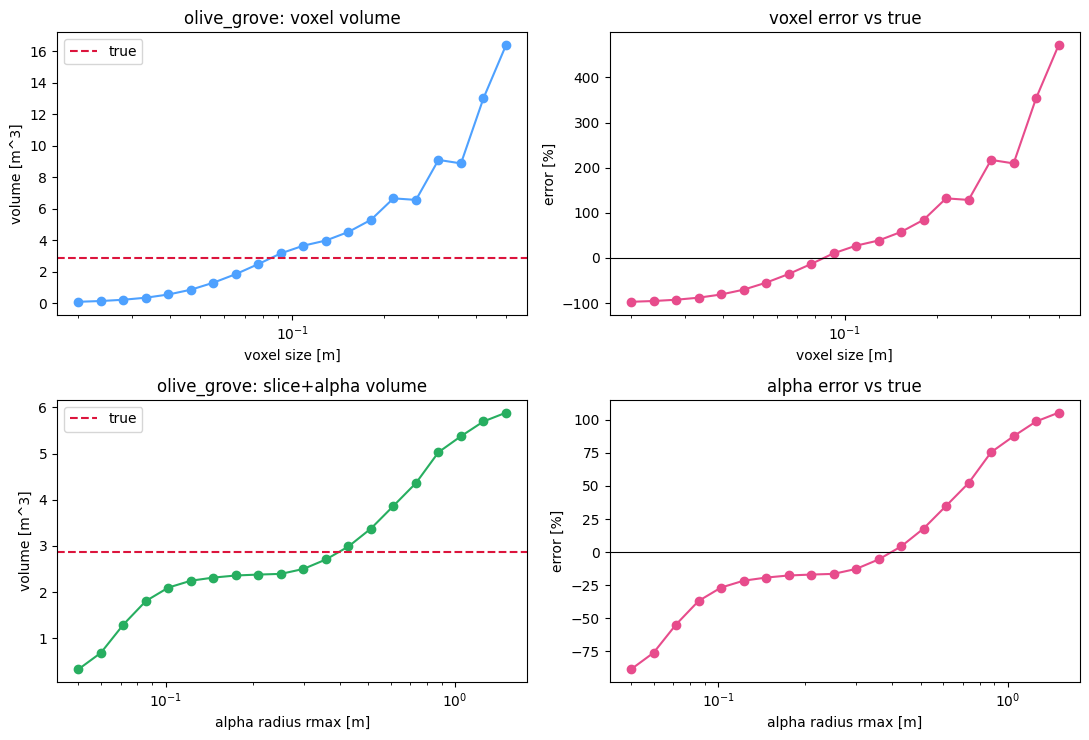

In [5]:
res_B = run_sweeps(cloud_B, gt_B, "olive_grove", IMG_DIR)

## 4 · Model C — "Two-row vineyard + alley" (two box canopy walls)

Two long, continuous canopy **boxes** separated by a 1 m alley. Disjoint, so
`V_true = 2 · (L·W·H)`. Each Z-slice contains two rectangles 1 m apart, so the
alpha-shape should keep them separate only while `rmax` stays below the alley width.

Model C: 32,640 pts | GT = 9.600 m^3 | alley = 1.0 m


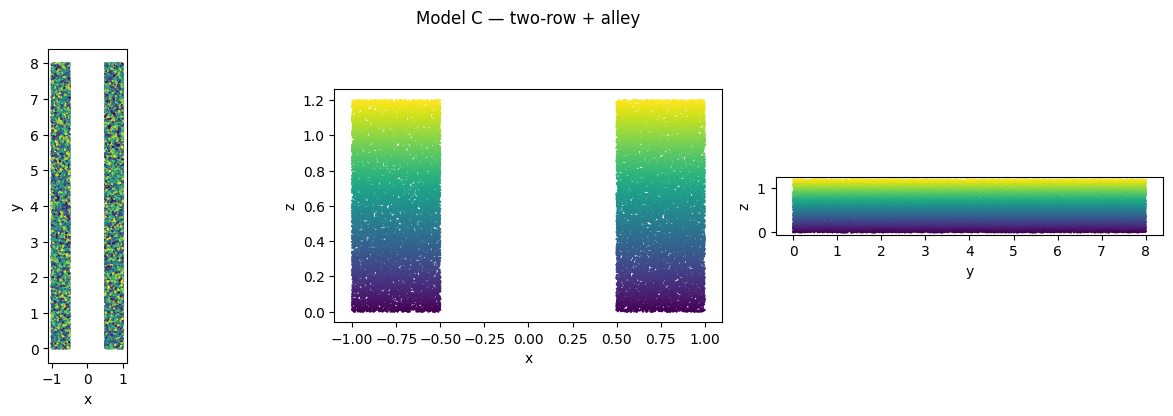

In [6]:
def build_two_row(rng):
    L, W, H = 8.0, 0.5, 1.2          # row length, canopy width, height
    ALLEY   = 1.0                    # gap between the two rows
    x_off   = ALLEY / 2 + W / 2
    gt = 2.0 * vol_box((W, L, H))
    dens = density_for(gt)
    n = max(50, int(round(vol_box((W, L, H)) * dens)))
    parts = [sample_box(n, (W, L, H), (sx, L / 2, H / 2), rng) for sx in (-x_off, x_off)]
    return np.vstack(parts), gt, ALLEY

cloud_C, gt_C, alley_C = build_two_row(RNG)
print(f"Model C: {len(cloud_C):,} pts | GT = {gt_C:.3f} m^3 | alley = {alley_C} m")
show_cloud(cloud_C, f"Model C — two-row + alley (GT = {gt_C:.3f} m^3)", RNG)
save_cloud_png(cloud_C, os.path.join(IMG_DIR, "cloud_two_row.png"), "Model C — two-row + alley", RNG)

[two_row]  GT = 9.600 m^3 | 32,640 pts
  voxel best : s   = 0.092 m  -> 9.558 m^3  (-0.4%)
  alpha best : rmax= 0.512 m  -> 9.470 m^3  (-1.4%)


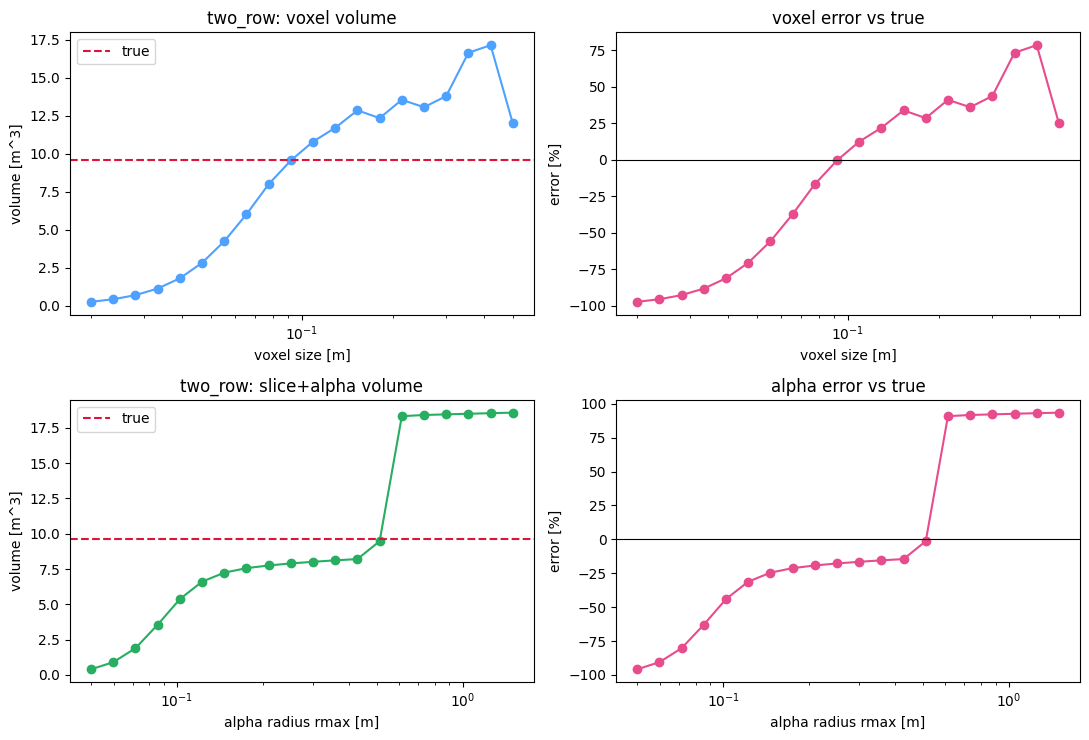


Note: the alpha-shape error should worsen sharply once rmax > alley/2 = 0.50 m,
because the concave hull then bridges the empty lane between the two rows.


In [7]:
res_C = run_sweeps(cloud_C, gt_C, "two_row", IMG_DIR)
print(f"\nNote: the alpha-shape error should worsen sharply once rmax > alley/2 = {alley_C/2:.2f} m,")
print("because the concave hull then bridges the empty lane between the two rows.")

## 5 · Summary

Best calibrated parameter per model and its residual error against the known volume.
Compare with the original notebook's vineyard result (s = 0.092 m / rmax = 0.428 m).

In [8]:
import pandas as pd
summary = pd.DataFrame([res_B, res_C])
summary.to_csv(os.path.join(IMG_DIR, "summary_extra.csv"), index=False)
print("saved:", os.path.join(IMG_DIR, "summary_extra.csv"))
summary

saved: /home/luka/Coding/DIPLOMSKI-RAD/vegetation-pcd-analysis/scripts/images/synthetic_validation_extra/summary_extra.csv


,model,true_m3,voxel_best_s_m,voxel_err_%,alpha_best_rmax_m,alpha_err_%
0,olive_grove,2.865,0.092,10.12,0.428,4.24
1,two_row,9.600,0.092,-0.44,0.512,-1.36
